Jason Stys

In [ ]:
import keras
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Dense, Dropout, Embedding
from keras.layers import SpatialDropout1D, Conv1D, GlobalMaxPooling1D
from keras.layers import LSTM
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.optimizers import Adam
import numpy as np
import os
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
# output directory name:
output_dir = 'model_output/LSTM_base'

# training:
epochs = 4
batch_size = 128

# vector-space embedding:
n_dim = 64
n_unique_words = 10000
max_review_length = 100
pad_type = trunc_type = 'pre'
drop_embed = 0.2

# LSTM layer architecture:
n_lstm = 256
drop_lstm = 0.2

In [ ]:
# load data
(x_train, y_train), (x_valid, y_valid) = imdb.load_data(num_words=n_unique_words)

# preprocess data
x_train = pad_sequences(
    x_train,
    maxlen=max_review_length,
    padding=pad_type,
    truncating=trunc_type,
    value=0
)

x_valid = pad_sequences(
    x_valid,
    maxlen=max_review_length,
    padding=pad_type,
    truncating=trunc_type,
    value=0
)

print('x_train shape:', x_train.shape)
print('x_valid shape:', x_valid.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
x_train shape: (25000, 100)
x_valid shape: (25000, 100)


In [ ]:
model = Sequential()

# 1st hidden layer
model.add(Embedding(
    input_dim=n_unique_words,
    output_dim=n_dim,
    input_shape=(max_review_length,)
))
model.add(SpatialDropout1D(drop_embed))

# 2nd hidden layer
model.add(LSTM(n_lstm, dropout=drop_lstm))

# output layer
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 100, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 256)            │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 968,961 (3.70 MB)

 Trainable params: 968,961 (3.70 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

best_model_path = os.path.join(output_dir, 'best_model.keras')

modelcheckpoint = ModelCheckpoint(
    filepath=best_model_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

Epoch 1/4
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5889 - loss: 0.6591
Epoch 1: val_accuracy improved from None to 0.82672, saving model to model_output/LSTM_base/best_model.keras

Epoch 1: finished saving model to model_output/LSTM_base/best_model.keras
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.6633 - loss: 0.5942 - val_accuracy: 0.8267 - val_loss: 0.3880
Epoch 2/4
190/196 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8546 - loss: 0.3413
Epoch 2: val_accuracy improved from 0.82672 to 0.84128, saving model to model_output/LSTM_base/best_model.keras

Epoch 2: finished saving model to model_output/LSTM_base/best_model.keras
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8574 - loss: 0.3356 - val_accuracy: 0.8413 - val_loss: 0.3617
Epoch 3/4
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8987 - loss: 0.2585
Epoch 3: val_accuracy did not improve from 0.84128
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8934 - loss: 0.2661 - val_accur

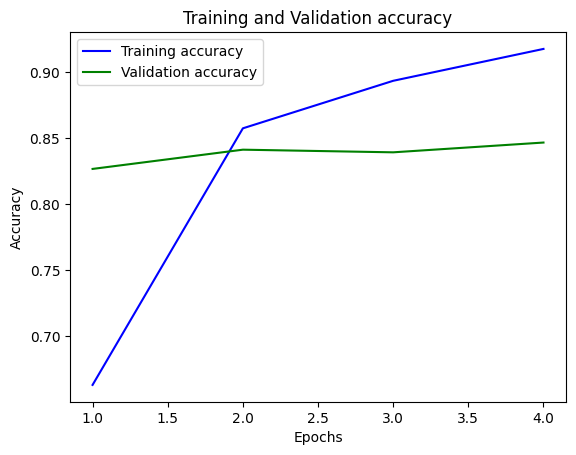

Base Model best validation accuracy: 84.67%
Base Model best epoch: 4


In [ ]:
history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(x_valid, y_valid),
    callbacks=[modelcheckpoint]
)

acc_train = history.history['accuracy']
acc_val = history.history['val_accuracy']
epoch_range = range(1, len(acc_train) + 1)

plt.plot(epoch_range, acc_train, 'b', label='Training accuracy')
plt.plot(epoch_range, acc_val, 'g', label='Validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

best_epoch = np.argmax(acc_val) + 1
best_val_acc = max(acc_val) * 100

print('Base Model best validation accuracy: {:.2f}%'.format(best_val_acc))
print('Base Model best epoch:', best_epoch)

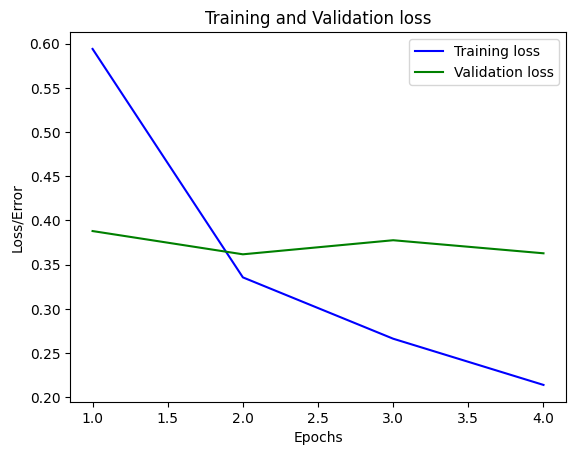

In [ ]:
loss_train = history.history['loss']
loss_val = history.history['val_loss']
epoch_range = range(1, len(loss_train) + 1)

plt.plot(epoch_range, loss_train, 'b', label='Training loss')
plt.plot(epoch_range, loss_val, 'g', label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss/Error')
plt.legend()
plt.show()

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


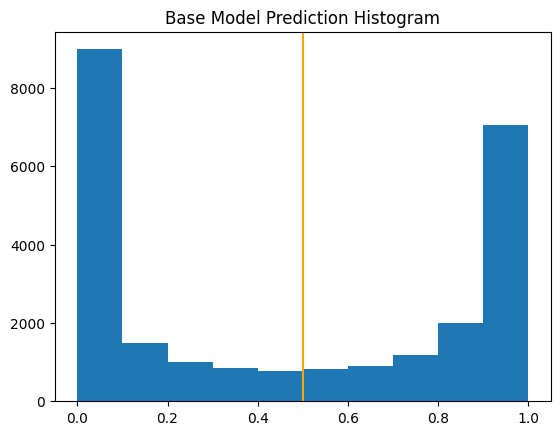

Base Model ROC-AUC: 92.62


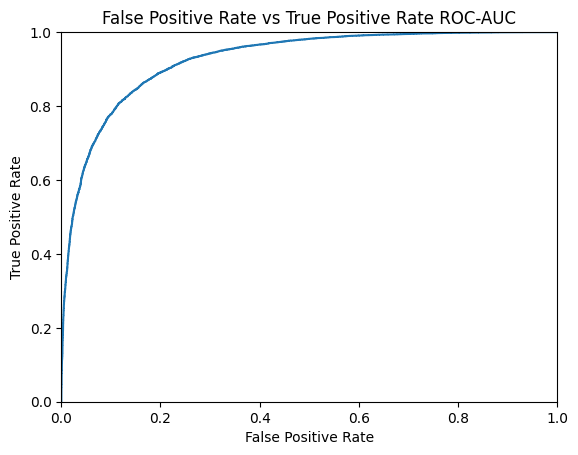

In [ ]:
best_model = keras.models.load_model(best_model_path)

y_hat = best_model.predict(x_valid)

plt.hist(y_hat)
_ = plt.axvline(x=0.5, color='orange')
plt.title('Base Model Prediction Histogram')
plt.show()

base_auc = roc_auc_score(y_valid, y_hat) * 100.0
print('Base Model ROC-AUC: {:.2f}'.format(base_auc))

fpr, tpr, thresholds = roc_curve(y_valid, y_hat)
plt.plot(fpr, tpr)
plt.axis([0, 1, 0, 1])
plt.title('False Positive Rate vs True Positive Rate ROC-AUC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

In [ ]:
# output directory name:
output_dir = 'model_output/LSTM_improved'

# training:
epochs = 8
batch_size = 64

# vector-space embedding:
n_dim = 128
n_unique_words = 10000
max_review_length = 100
pad_type = trunc_type = 'pre'
drop_embed = 0.3

# LSTM layer architecture:
n_lstm = 128
drop_lstm = 0.3

# optimizer:
learning_rate = 0.0005

In [ ]:
improved_model = Sequential()

# 1st hidden layer
improved_model.add(Embedding(
    input_dim=n_unique_words,
    output_dim=n_dim,
    input_shape=(max_review_length,)
))
improved_model.add(SpatialDropout1D(drop_embed))

# 2nd hidden layer
improved_model.add(LSTM(n_lstm, dropout=drop_lstm))

# output layer
improved_model.add(Dense(1, activation='sigmoid'))

improved_model.summary()

improved_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=learning_rate),
    metrics=['accuracy']
)

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

best_model_path = os.path.join(output_dir, 'best_model.keras')

modelcheckpoint = ModelCheckpoint(
    filepath=best_model_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 100, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,411,713 (5.39 MB)

 Trainable params: 1,411,713 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
385/391 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6673 - loss: 0.5844
Epoch 1: val_accuracy improved from None to 0.82344, saving model to model_output/LSTM_improved/best_model.keras

Epoch 1: finished saving model to model_output/LSTM_improved/best_model.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7637 - loss: 0.4741 - val_accuracy: 0.8234 - val_loss: 0.4217
Epoch 2/8
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8757 - loss: 0.3030
Epoch 2: val_accuracy improved from 0.82344 to 0.85500, saving model to model_output/LSTM_improved/best_model.keras

Epoch 2: finished saving model to model_output/LSTM_improved/best_model.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8778 - loss: 0.2965 - val_accuracy: 0.8550 - val_loss: 0.3307
Epoch 3/8
386/391 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9088 - loss: 0.2351
Epoch 3: val_accuracy did not improve from 0.85500
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9037 - loss: 0.

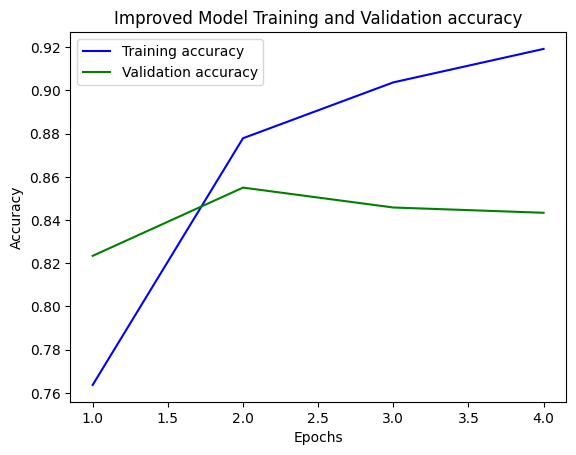

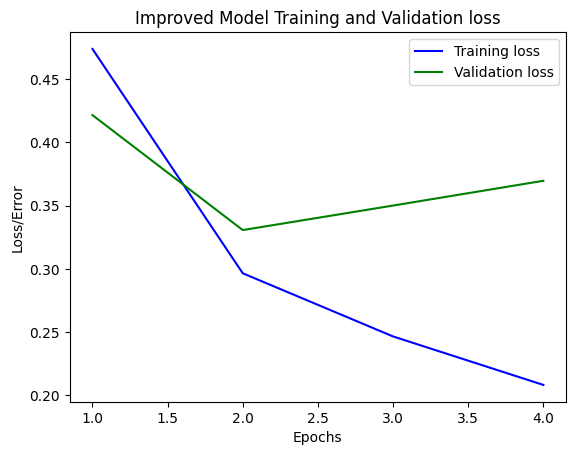

Improved Model best validation accuracy: 85.50%
Improved Model best epoch: 2


In [ ]:
history = improved_model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(x_valid, y_valid),
    callbacks=[modelcheckpoint, earlystop]
)

acc_train = history.history['accuracy']
acc_val = history.history['val_accuracy']
epoch_range = range(1, len(acc_train) + 1)

plt.plot(epoch_range, acc_train, 'b', label='Training accuracy')
plt.plot(epoch_range, acc_val, 'g', label='Validation accuracy')
plt.title('Improved Model Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

loss_train = history.history['loss']
loss_val = history.history['val_loss']

plt.plot(epoch_range, loss_train, 'b', label='Training loss')
plt.plot(epoch_range, loss_val, 'g', label='Validation loss')
plt.title('Improved Model Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss/Error')
plt.legend()
plt.show()

best_epoch = np.argmax(acc_val) + 1
best_val_acc = max(acc_val) * 100

print('Improved Model best validation accuracy: {:.2f}%'.format(best_val_acc))
print('Improved Model best epoch:', best_epoch)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


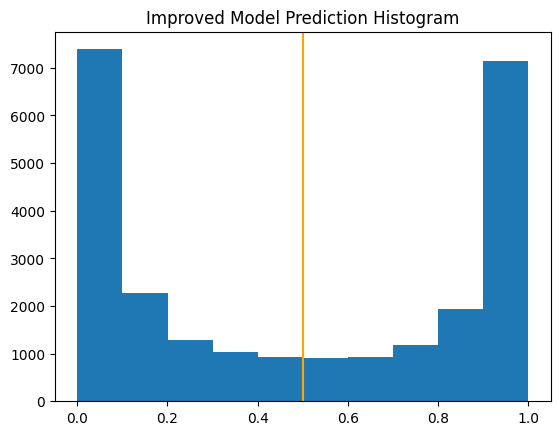

Improved Model ROC-AUC: 93.38


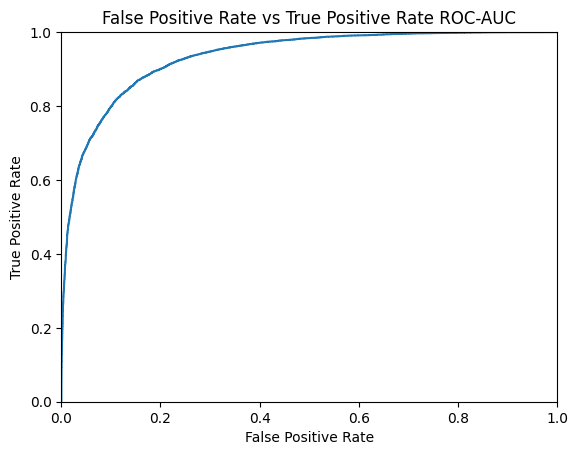

In [ ]:
best_model = keras.models.load_model(best_model_path)

y_hat = best_model.predict(x_valid)

plt.hist(y_hat)
_ = plt.axvline(x=0.5, color='orange')
plt.title('Improved Model Prediction Histogram')
plt.show()

improved_auc = roc_auc_score(y_valid, y_hat) * 100.0
print('Improved Model ROC-AUC: {:.2f}'.format(improved_auc))

fpr, tpr, thresholds = roc_curve(y_valid, y_hat)
plt.plot(fpr, tpr)
plt.axis([0, 1, 0, 1])
plt.title('False Positive Rate vs True Positive Rate ROC-AUC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()